Сначала загрузим все необходимые модели из предыдущих этапов:

In [ ]:
import matplotlib.pyplot as plt
import torch
import matplotlib.patches as patches
import random
from google.colab import drive
import pandas as pd
import numpy as np
import seaborn
import cv2
import os
from time import time
from torch import nn
from tqdm import tqdm
from torch.utils.data import Dataset
from PIL import Image
from torchvision.transforms import functional as TF
from torchvision import transforms
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.transforms import ToPILImage
import torchvision.models as models
from itertools import combinations
from torch.nn.functional import cosine_similarity
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
class Residual(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        mid_channels = out_channels // 2

        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, mid_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        self.conv2 = nn.Conv2d(mid_channels, mid_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_channels)

        self.conv3 = nn.Conv2d(mid_channels, out_channels, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        skip = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + skip)

class Hourglass(nn.Module):
    def __init__(self, depth, channels):
        super().__init__()
        self.depth = depth
        self.channels = channels

        self.skip = Residual(channels, channels)
        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            Residual(channels, channels)
        )

        if depth > 1:
            self.inner = Hourglass(depth - 1, channels)
        else:
            self.inner = Residual(channels, channels)

        self.up = Residual(channels, channels)

    def forward(self, x):
        skip = self.skip(x)
        x = self.down(x)
        x = self.inner(x)
        x = self.up(F.interpolate(x, scale_factor=2, mode='nearest'))
        return x + skip

class HourglassBlock(nn.Module):
    def __init__(self, depth, channels, num_keypoints):
        super().__init__()
        self.hourglass = Hourglass(depth, channels)
        self.res = Residual(channels, channels)
        self.out_heatmap = nn.Conv2d(channels, num_keypoints, kernel_size=1)

        self.out_feature = nn.Conv2d(channels, channels, kernel_size=1)
        self.out_heatmap_to_feat = nn.Conv2d(num_keypoints, channels, kernel_size=1)

    def forward(self, x):
        hg = self.hourglass(x)
        feat = self.res(hg)
        heatmap = self.out_heatmap(feat)
        feat_next = x + self.out_feature(feat) + self.out_heatmap_to_feat(heatmap)
        return heatmap, feat_next

class StackedHourglassNet(nn.Module):
    def __init__(self, num_stacks, num_blocks, channels, num_keypoints):
        super().__init__()
        self.pre = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            Residual(64, 128),
            nn.MaxPool2d(2),
            Residual(128, 128),
            Residual(128, channels)
        )

        self.stacks = nn.ModuleList([
            HourglassBlock(num_blocks, channels, num_keypoints)
            for _ in range(num_stacks)
        ])

    def forward(self, x):
        x = self.pre(x)
        outputs = []

        for stack in self.stacks:
            heatmap, x = stack(x)
            outputs.append(heatmap)

        return outputs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
hourglass = StackedHourglassNet(num_stacks=2, num_blocks=4, channels=128, num_keypoints=5)
hourglass.load_state_dict(torch.load("/content/drive/MyDrive/Share/Face_Recognition/shg_amazing.pth", map_location=device))
hourglass = hourglass.to(device).eval()

In [ ]:
class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        base_model = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(base_model.children())[:-1])
        self.embedding = nn.Linear(base_model.fc.in_features, embedding_dim)

    def forward(self, x):
        x = self.backbone(x)
        x = torch.flatten(x, 1)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)

def load_face_model(model_type, checkpoint_path, num_classes = 500, device=device):
    if model_type == 'ce':
        model = models.resnet50(pretrained=True)
        model.fc = nn.Sequential(
            nn.Linear(model.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    elif model_type in ('arcface', 'arcface_ce', 'arcface_triplet'):
        class ArcModel(nn.Module):
            def __init__(self):
                super().__init__()
                self.backbone = models.resnet50(pretrained=True)
                self.backbone.fc = nn.Sequential(
                    nn.Linear(self.backbone.fc.in_features, 256),
                    nn.ReLU(),
                    nn.Dropout(0.3)
                )
                self.classifier = nn.Linear(256, num_classes, bias=False)

            def forward(self, x):
                x = self.backbone(x)
                return self.classifier(x)

        model = ArcModel()

    elif model_type == 'triplet':
        model = EmbeddingNet()

    else:
        raise ValueError(f"Unknown model type: {model_type}")

    state = torch.load(checkpoint_path, map_location=device)

    if 'backbone_state' in state and 'classifier_state' in state:
        model.backbone.load_state_dict(state['backbone_state'])
        model.classifier.load_state_dict(state['classifier_state'])
    else:
        if 'model_state' in state:
            state = state['model_state']
        elif 'model_state_dict' in state:
            state = state['model_state_dict']
        elif 'model' in state:
            state = state['model']
        model.load_state_dict(state)

    model.to(device)
    model.eval()
    return model


In [ ]:
base_path = "/content/drive/MyDrive/Share/Face_Recognition"

In [ ]:
ce_model = load_face_model("ce", f"{base_path}/resnet_ce_best.pth")
arc_model = load_face_model("arcface", f"{base_path}/resnet_arcface_best.pth")
triplet_model = load_face_model("triplet", f"{base_path}/resnet_triplet_best.pth")
ce_arc_model = load_face_model("arcface_ce", f"{base_path}/resnet_ce_arcface_best.pth")
triplet_arc_model = load_face_model("arcface_triplet", f"{base_path}/resnet_arcface2_triplet1.pth")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s]


## Identification Rate Metric

При обучении модели для распознавания лиц с помощью CE (кросс-энтропии) мы можем считать метрику accuracy как индикатор того, насколько хорошо наша модель работает. Но у accuracy тут есть недостаток: она не сможет померить, насколько хорошо наша модель работает на лицах людей, которых нет в обучающей выборке.  

Чтобы это исправить, придумали новую метрику: **identification rate**. Вот как она работает:

Создадим два набора изображений лиц: query и distractors. Никакие лица из этих наборов не должны содержаться в обучающем и валидационном датасете.

1. посчитаем косинусные расстояния между лицами, соответствующими одним и тем же людям из query части. Например, пусть одному человеку соответствуют три фото в query: 01.jpg, 02.jpg, 03.jpg. Тогда считаем три косинусных расстояния между всеми тремя парами из этих фото.
2. посчитаем косинусные расстояния между лицами, соответствующими разным людям из query части.
3. посчитаем косинусные расстояния между всеми парами лиц из query и distractors. Т.е. пара — это (лицо из query, лицо из distractors). Всего получится |query|*|distractors| пар.
4. Сложим количества пар, полученных на 2 и 3 шагах. Это количество false пар.
5. Зафиксируем **FPR** (false positive rate). Пусть, например, будет 0.01. FPR, умноженный на количество false пар из шага 4 — это разрешенное количество false positives, которые мы разрешаем нашей модели. Обозначим это количество через N.
6. Отсортируем все значения косинусных расстояний false пар. N — ое по счету значение расстояния зафиксируем как **пороговое расстояние**.
7. Посчитаем количество positive пар с шага 1, которые имеют косинусное расстояние меньше, чем пороговое расстояние. Поделим это количество на общее количество positive пар с шага 1. Это будет TPR (true positive rate) — итоговое значение нашей метрики.

Такая метрика обычно обозначается как TPR@FPR=0.01. FPR может быть разным. Приразных FPR будет получаться разное TPR.

Смысл этой метрики в том, что мы фиксируем вероятность ошибки вида false positive, т.е. когда "сеть сказала, что это один и тот же человек, но это не так", считаем порог косинусного расстояния для этого значения ошибки, потом берем все positive пары и смотрим, у скольких из них расстояние меньше этого порога. Т.е. насколько точно наша сеть ищет похожие лица при заданной вероятности ошибки вида false positive.

**Для подсчета метрик, то вам нужно разбить данные на query и distractors самим.**

Делается это примерно так:
- Выбраете несколько id, которые не использовались при тренировке моделей, и помещаете их в query set;
- Выбираете несколько id, которые не использовались при тренировке моделей и не входят в query, и помещаете их в distractors set. Обычно distractors set должен быть сильно больше, чем query set.
- Обрабатываете картинки из query и distractors тем же способом, что картинки для обучения сети.


Обратите внимание, что если картинок в query и distractors очень много, то полученных пар картинок в пунктах 1-2-3 алгоритма подсчета TPR@FPR будет очень-очень много. Чтобы код подсчета работал быстрее, ограничивайте размеры этих датасетов. Контролируйте, сколько значений расстояний вы считаете.

Ниже дан шаблон кода для реализации FPR@TPR метрики и ячейки с тестами. Тесты проверяют, что ваш код в ячейках написан правильно.

## План заданий

* Правильно разбить датасет на query и distractors
* Реализовать метрику и пройти все тесты
* Подгрузить все модели, обученные на разных лоссах и сравнить их метрики

## Шаблон кода для Identificaton rate metric (TPR@FPR)

Загрузим данные из CelebA

In [ ]:
base_path = "/content/drive/MyDrive/Share/Face_Recognition/CelebA"
landmarks_path = f"{base_path}/list_landmarks_align_celeba.txt"
identity_path  = f"{base_path}/identity_CelebA.txt"
partition_path = f"{base_path}/list_eval_partition.txt"
landmarks_df = pd.read_csv(landmarks_path, sep='\s+', skiprows=1)
filenames = [(str(i + 1).zfill(6) + ".jpg") for i in range(len(landmarks_df))]
landmarks_df.insert(0, "filename", filenames)

identity_df  = pd.read_csv(identity_path, sep='\s+', header=None, names=["filename", "identity"])
partition_df = pd.read_csv(partition_path, sep='\s+', header=None, names=["filename", "partition"])
df = identity_df.merge(landmarks_df, on="filename").merge(partition_df, on="filename")

print(df.head())

     filename  identity  lefteye_x  lefteye_y  righteye_x  righteye_y  nose_x  \
0  000001.jpg      2880         69        109         106         113      77   
1  000002.jpg      2937         69        110         107         112      81   
2  000003.jpg      8692         76        112         104         106     108   
3  000004.jpg      5805         72        113         108         108     101   
4  000005.jpg      9295         66        114         112         112      86   

   nose_y  leftmouth_x  leftmouth_y  rightmouth_x  rightmouth_y  partition  
0     142           73          152           108           154          0  
1     135           70          151           108           153          0  
2     128           74          156            98           158          0  
3     138           71          155           101           151          0  
4     119           71          147           104           150          0  


In [ ]:
df_train = df[df["partition"] == 0].reset_index(drop=True)
df_val   = df[df["partition"] == 1].reset_index(drop=True)
df_test  = df[df["partition"] == 2].reset_index(drop=True)

print(f"Train: {len(df_train)}")
print(f"Val:   {len(df_val)}")
print(f"Test:  {len(df_test)}")

Train: 162770
Val:   19867
Test:  19962


Нам нужно избавиться от всего, что было задействовано в обучениях предыдущих моделей

In [ ]:
train_df_small = df_train.iloc[:7500].reset_index(drop=True)
val_df_small   = df_val.iloc[:1500].reset_index(drop=True)
used_ids = pd.concat([train_df_small, val_df_small])['identity'].unique()
available_df = df[~df['identity'].isin(used_ids)].copy()

top_identities = df['identity'].value_counts().head(500).index.tolist()
classifier_df = df[df['identity'].isin(top_identities)].reset_index(drop=True)

print(f"Выбрано {len(top_identities)} identity, всего {len(classifier_df)} изображений")
print("Фото на одного человека (min / max):",
      classifier_df['identity'].value_counts().min(),
      "/",
      classifier_df['identity'].value_counts().max())

Выбрано 500 identity, всего 15038 изображений
Фото на одного человека (min / max): 30 / 35


После глобального экстерминатуса посмотрим на выживших

In [ ]:
excluded_ids = set(used_ids).union(set(top_identities))
remaining_df = df[~df['identity'].isin(excluded_ids)].copy()
print("Осталось уникальных identity:", remaining_df['identity'].nunique())
print("Мин/макс фото на identity:",
      remaining_df['identity'].value_counts().min(),
      '/',
      remaining_df['identity'].value_counts().max())

Осталось уникальных identity: 4682
Мин/макс фото на identity: 1 / 30


Неплохо. Теперь:  
- Считаем количество фото на identity;
- Берем в кандидаты для query тех, у кого не менее трех фото;
- Остальных берем в кандидаты для distractors.

In [ ]:
from collections import Counter
import random

id_counts = remaining_df['identity'].value_counts()
query_candidates = id_counts[id_counts >= 3].index.tolist()
distractor_candidates = id_counts[~id_counts.index.isin(query_candidates)].index.tolist()

print(f"Доступно query_candidates: {len(query_candidates)}")
print(f"Доступно distractor_candidates: {len(distractor_candidates)}")

Доступно query_candidates: 4353
Доступно distractor_candidates: 329


Берём всех возможных distractor identity, коих набралось 329 штук, и, чтобы не было дисбаланса, уменьшим query тоже до, например, 50. Так мы и разнообразие создадим, и от ожидания не умрем.

In [ ]:
distractor_ids = distractor_candidates
query_ids = random.sample(query_candidates, k=50)

print(f"Выбрано {len(query_ids)} identity для query и {len(distractor_ids)} для distractors")

Выбрано 50 identity для query и 329 для distractors


Создаем датафрейм

In [ ]:
query_df = remaining_df[remaining_df['identity'].isin(query_ids)].reset_index(drop=True)
distractor_df = remaining_df[remaining_df['identity'].isin(distractor_ids)].reset_index(drop=True)

Ну и дальше круги предобработочного SHG-ада

In [ ]:

!unzip -q /content/drive/MyDrive/Share/Face_Recognition/CelebA/img_align_celeba.zip -d /content/img_celeba


In [ ]:
img_dir = "/content/img_celeba/img_align_celeba"

In [ ]:
class CelebAHeatmapAugmented(Dataset):
    def __init__(self, img_dir, landmarks_df, image_size=256, heatmap_size=64, sigma=1.5):
        self.img_dir = img_dir
        self.landmarks_df = landmarks_df
        self.image_size = image_size
        self.heatmap_size = heatmap_size
        self.sigma = sigma

    def __len__(self):
        return len(self.landmarks_df)

    def __getitem__(self, idx):
        row = self.landmarks_df.iloc[idx]
        fname = row['filename'].strip()
        img_path = os.path.join(self.img_dir, fname)

        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size

        keypoints = np.array([
            [row['lefteye_x'], row['lefteye_y']],
            [row['righteye_x'], row['righteye_y']],
            [row['nose_x'], row['nose_y']],
            [row['leftmouth_x'], row['leftmouth_y']],
            [row['rightmouth_x'], row['rightmouth_y']]
        ], dtype=np.float32)

        scale_x = self.image_size / orig_w
        scale_y = self.image_size / orig_h
        keypoints *= [scale_x, scale_y]
        image = image.resize((self.image_size, self.image_size))
        image_np = np.array(image)

        angle = random.uniform(-45, 45)
        scale = random.uniform(0.9, 1.1)
        tx = random.uniform(-0.05, 0.05) * self.image_size
        ty = random.uniform(-0.05, 0.05) * self.image_size
        center = (self.image_size / 2, self.image_size / 2)

        M = cv2.getRotationMatrix2D(center, angle, scale)
        M[:, 2] += [tx, ty]

        image_affine = cv2.warpAffine(image_np, M, (self.image_size, self.image_size), borderMode=cv2.BORDER_REFLECT)
        keypoints_aug = np.hstack([keypoints, np.ones((5, 1))]) @ M.T
        keypoints_aug = np.clip(keypoints_aug, 0, self.image_size - 1)

        image_tensor = TF.to_tensor(Image.fromarray(image_affine))
        heatmaps = self.generate_heatmaps(keypoints_aug)

        return image_tensor, torch.tensor(heatmaps, dtype=torch.float32)

    def generate_heatmaps(self, keypoints):
        hms = np.zeros((len(keypoints), self.heatmap_size, self.heatmap_size), dtype=np.float32)
        for i, (x, y) in enumerate(keypoints):
            x = x * self.heatmap_size / self.image_size
            y = y * self.heatmap_size / self.image_size
            xx, yy = np.meshgrid(np.arange(self.heatmap_size), np.arange(self.heatmap_size))
            hms[i] = np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * self.sigma**2))
        return hms

In [ ]:
query_dataset = CelebAHeatmapAugmented(
    img_dir,
    landmarks_df=query_df,
    image_size=256,
    heatmap_size=64,
    sigma=2
)

distractor_dataset = CelebAHeatmapAugmented(
    img_dir,
    landmarks_df=distractor_df,
    image_size=256,
    heatmap_size=64,
    sigma=2
)


In [ ]:
def align_and_save_faces_with_labels(dataset, labels, model, save_dir, device=device, output_size=(112, 112), limit=None):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()

    to_pil = ToPILImage()

    def heatmap_to_coords(hms):
        coords = []
        for hm in hms:
            y, x = np.unravel_index(np.argmax(hm), hm.shape)
            coords.append([x * 4, y * 4])
        return np.array(coords, dtype=np.float32)

    standard = np.array([
        [30.2946, 51.6963],
        [65.5318, 51.5014],
        [48.0252, 71.7366],
        [33.5493, 92.3655],
        [62.7299, 92.2041]
    ], dtype=np.float32)

    if output_size[0] != 112:
        standard *= (output_size[0] / 112)

    count = 0
    for i in range(len(dataset)):
        if limit and count >= limit:
            break

        try:
            img_tensor, _ = dataset[i]
            identity = labels[i]
            person_dir = os.path.join(save_dir, str(identity))
            os.makedirs(person_dir, exist_ok=True)

            img_pil = to_pil(img_tensor.cpu())
            input_tensor = T.Resize((256, 256))(img_pil)
            input_tensor = T.ToTensor()(input_tensor).unsqueeze(0).to(device)

            with torch.no_grad():
                pred_heatmap = model(input_tensor)[-1][0].cpu().numpy()

            pred_pts = heatmap_to_coords(pred_heatmap)
            M = cv2.estimateAffinePartial2D(pred_pts, standard, method=cv2.LMEDS)[0]
            img_cv = np.array(img_pil.convert('RGB'))
            aligned = cv2.warpAffine(img_cv, M, output_size, borderValue=0)

            filename = os.path.join(person_dir, f"aligned_{count:04d}.jpg")
            Image.fromarray(aligned).save(filename)
            count += 1

        except Exception as e:
            print(f"[SKIP] Ошибка на индексе {i}: {e}")

    print(f"Сохранено {count} лиц в {save_dir} по папкам identity")


Создаем архив с фото из query и distractors

In [ ]:
align_and_save_faces_with_labels(
    dataset=query_dataset,
    labels=query_df['identity'].tolist(),
    model=hourglass,
    save_dir='aligned_eval/query',
    device=device,
    output_size=(112, 112)
)

align_and_save_faces_with_labels(
    dataset=distractor_dataset,
    labels=distractor_df['identity'].tolist(),
    model=hourglass,
    save_dir='aligned_eval/distractors',
    device=device,
    output_size=(112, 112)
)

Сохранено 812 лиц в aligned_eval/query по папкам identity
Сохранено 617 лиц в aligned_eval/distractors по папкам identity


In [ ]:
import shutil
import os
from glob import glob

def collect_aligned_paths_and_labels(root_dir):
    image_paths = glob(os.path.join(root_dir, "*", "*.jpg"))
    labels = [os.path.basename(os.path.dirname(p)) for p in image_paths]
    return image_paths, labels

shutil.make_archive("aligned_eval_query", "zip", "aligned_eval/query")
shutil.make_archive("aligned_eval_distractors", "zip", "aligned_eval/distractors")

query_paths, query_labels = collect_aligned_paths_and_labels("aligned_eval/query")
distractor_paths, distractor_labels = collect_aligned_paths_and_labels("aligned_eval/distractors")

print(f"Query: {len(query_paths)} изображений, {len(set(query_labels))} identity")
print(f"Distractors: {len(distractor_paths)} изображений, {len(set(distractor_labels))} identity")

Query: 812 изображений, 50 identity
Distractors: 617 изображений, 329 identity


Составим словари для наших query и distractors

In [ ]:
from collections import defaultdict

query_dict = defaultdict(list)
for path, label in zip(query_paths, query_labels):
    query_dict[label].append(path)

distractor_dict = defaultdict(list)
for path, label in zip(distractor_paths, distractor_labels):
    distractor_dict[label].append(path)

Посмотрим на них

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob

def show_faces_from_folder(folder_path, title=None, image_size=(112, 112), max_per_row=6):
    img_paths = sorted(glob(os.path.join(folder_path, "*.jpg")))
    n_images = len(img_paths)

    if title:
        print(f"\n {title}")

    n_cols = min(n_images, max_per_row)
    n_rows = (n_images + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.2 * n_rows))

    if isinstance(axes, plt.Axes):
        axes = [[axes]]
    elif isinstance(axes[0], plt.Axes):
        axes = [axes]  # 1 row
    else:
        axes = axes

    for i in range(n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row][col] if n_rows > 1 else axes[0][col]
        ax.axis("off")

        if i < n_images:
            img = Image.open(img_paths[i]).resize(image_size)
            ax.imshow(img)
            ax.set_title(os.path.basename(img_paths[i]), fontsize=8)

    plt.tight_layout()
    plt.show()


In [ ]:
show_faces_from_folder(folder_path="/content/aligned_eval/query/1154", title="Query")
show_faces_from_folder(folder_path="/content/aligned_eval/distractors/10124", title="Distractor")

Output hidden; open in https://colab.research.google.com to view.

Различаются, ура.

Далее реализуем все необходимые функции из ноутбука с заданием и пройдем все тесты:

In [ ]:
from PIL import Image
import torchvision.transforms as T
import torch.nn.functional as F
preprocess = T.Compose([
    T.Resize((112, 112)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
def compute_embeddings(model, images_list):
    model.eval()
    embeddings = []

    with torch.no_grad():
        for path in images_list:
            img = Image.open(path).convert('RGB')
            x = preprocess(img).unsqueeze(0).to(device)
            emb = model(x)
            emb = F.normalize(emb, dim=1)
            embeddings.append(emb.squeeze(0).cpu())

    return embeddings

In [ ]:
def compute_cosine_query_pos(query_dict, query_img_names, query_embeddings):
    """
    compute cosine similarities between positive pairs from query (stage 1)
    params:
    query_dict: dict {class: [image_name_1, image_name_2, ...]}. Key: class in
                the dataset. Value: images corresponding to that class
    query_img_names: list of images names
    query_embeddings: list of embeddings corresponding to query_img_names
    output:
    list of floats: similarities between embeddings corresponding
                    to the same people from query list
    """
    path_to_emb = dict(zip(query_img_names, query_embeddings))
    sims = []

    for class_id, img_list in query_dict.items():
        for img1, img2 in combinations(img_list, 2):
            emb1 = path_to_emb[img1]
            emb2 = path_to_emb[img2]

            if not isinstance(emb1, torch.Tensor):
                emb1 = torch.tensor(emb1, dtype=torch.float32)
            if not isinstance(emb2, torch.Tensor):
                emb2 = torch.tensor(emb2, dtype=torch.float32)

            sim = cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
            sims.append(sim)

    return sims

def compute_cosine_query_neg(query_dict, query_img_names, query_embeddings):
    '''
    compute cosine similarities between negative pairs from query (stage 2)
    params:
      query_dict: dict {class: [image_name_1, image_name_2, ...]}. Key: class in
                  the dataset. Value: images corresponding to that class
      query_img_names: list of images names
      query_embeddings: list of embeddings corresponding to query_img_names
    output:
      list of floats: similarities between embeddings corresponding
                      to different people from query list
    '''
    """
    Косинусные похожести между отрицательными парами внутри query
    """
    path_to_emb = dict(zip(query_img_names, query_embeddings))
    sims = []

    all_classes = list(query_dict.keys())

    for i in range(len(all_classes)):
        for j in range(i+1, len(all_classes)):
            class_i = query_dict[all_classes[i]]
            class_j = query_dict[all_classes[j]]

            for img_i in class_i:
                for img_j in class_j:
                    emb_i = path_to_emb[img_i]
                    emb_j = path_to_emb[img_j]
                    if not isinstance(emb_i, torch.Tensor):
                        emb_i = torch.tensor(emb_i, dtype=torch.float32)
                    if not isinstance(emb_j, torch.Tensor):
                        emb_j = torch.tensor(emb_j, dtype=torch.float32)
                    sim = cosine_similarity(emb_i.unsqueeze(0), emb_j.unsqueeze(0)).item()
                    sims.append(sim)

    return sims

def compute_cosine_query_distractors(query_embeddings, distractors_embeddings):
    '''
    compute cosine similarities between negative pairs from query and distractors
    (stage 3)
    params:
      query_embeddings: list of embeddings corresponding to query_img_names
      distractors_embeddings: list of embeddings corresponding to distractors_img_names
    output:
      list of floats: similarities between pairs of people (q, d), where q is
                      embedding corresponding to photo from query, d —
                      embedding corresponding to photo from distractors
    '''
    """
    Косинусные похожести между query и distractors
    """
    sims = []
    for emb_q in query_embeddings:
        for emb_d in distractors_embeddings:
            if not isinstance(emb_q, torch.Tensor):
                emb_q = torch.tensor(emb_q, dtype=torch.float32)
            if not isinstance(emb_d, torch.Tensor):
                emb_d = torch.tensor(emb_d, dtype=torch.float32)

            sim = cosine_similarity(emb_q.unsqueeze(0), emb_d.unsqueeze(0)).item()
            sims.append(sim)
    return sims

Ячейка ниже проверяет, что код работает верно:

In [ ]:
test_query_dict = {
    2876: ['1.jpg', '2.jpg', '3.jpg'],
    5674: ['5.jpg'],
    864:  ['9.jpg', '10.jpg'],
}
test_query_img_names = ['1.jpg', '2.jpg', '3.jpg', '5.jpg', '9.jpg', '10.jpg']
test_query_embeddings = [
                    [1.56, 6.45,  -7.68],
                    [-1.1 , 6.11,  -3.0],
                    [-0.06,-0.98,-1.29],
                    [8.56, 1.45,  1.11],
                    [0.7,  1.1,   -7.56],
                    [0.05, 0.9,   -2.56],
]

test_distractors_img_names = ['11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg']

test_distractors_embeddings = [
                    [0.12, -3.23, -5.55],
                    [-1,   -0.01, 1.22],
                    [0.06, -0.23, 1.34],
                    [-6.6, 1.45,  -1.45],
                    [0.89,  1.98, 1.45],
]

test_cosine_query_pos = compute_cosine_query_pos(test_query_dict, test_query_img_names,
                                            test_query_embeddings)
test_cosine_query_neg = compute_cosine_query_neg(test_query_dict, test_query_img_names,
                                            test_query_embeddings)
test_cosine_query_distractors = compute_cosine_query_distractors(test_query_embeddings,
                                                            test_distractors_embeddings)

In [ ]:
true_cosine_query_pos = [0.8678237233650096, 0.21226104378511604,
                         -0.18355866977496182, 0.9787437979250561]
assert np.allclose(sorted(test_cosine_query_pos), sorted(true_cosine_query_pos)), \
      "A mistake in compute_cosine_query_pos function"

true_cosine_query_neg = [0.15963231223161822, 0.8507997093616965, 0.9272761484302097,
                         -0.0643994061127092, 0.5412660901220571, 0.701307100338029,
                         -0.2372575528216902, 0.6941032794522218, 0.549425446066643,
                         -0.011982733001947084, -0.0466679194884999]
assert np.allclose(sorted(test_cosine_query_neg), sorted(true_cosine_query_neg)), \
      "A mistake in compute_cosine_query_neg function"

true_cosine_query_distractors = [0.3371426578637511, -0.6866465610863652, -0.8456563512871669,
                                 0.14530087113136106, 0.11410510307646118, -0.07265097629002357,
                                 -0.24097699660707042,-0.5851992679925766, 0.4295494455718534,
                                 0.37604478596058194, 0.9909483738948858, -0.5881093317868022,
                                 -0.6829712976642919, 0.07546364489032083, -0.9130970963915521,
                                 -0.17463101988684684, -0.5229363015558941, 0.1399896725311533,
                                 -0.9258034013399499, 0.5295114163723346, 0.7811585442749943,
                                 -0.8208760031249596, -0.9905139680301821, 0.14969764653247228,
                                 -0.40749654525418444, 0.648660814944824, -0.7432584300096284,
                                 -0.9839696492435877, 0.2498741082804709, -0.2661183373780491]
assert np.allclose(sorted(test_cosine_query_distractors), sorted(true_cosine_query_distractors)), \
      "A mistake in compute_cosine_query_distractors function"

И, наконец, финальная функция, которая считает IR metric:

In [ ]:
def compute_ir(cosine_query_pos, cosine_query_neg, cosine_query_distractors,
               fpr=0.1):
    '''
    compute identification rate using precomputer cosine similarities between pairs
    at given fpr
    params:
      cosine_query_pos: cosine similarities between positive pairs from query
      cosine_query_neg: cosine similarities between negative pairs from query
      cosine_query_distractors: cosine similarities between negative pairs
                                from query and distractors
      fpr: false positive rate at which to compute TPR
    output:
      float: threshold for given fpr
      float: TPR at given FPR
    '''
    pos_sims = np.array(cosine_query_pos)
    neg_sims = np.array(cosine_query_neg + cosine_query_distractors)

    # Отсортировать отрицательные по убыванию
    sorted_neg = np.sort(neg_sims)[::-1]

    # Вычислить N — сколько false positives разрешено
    N = int(fpr * len(sorted_neg))

    # Пороговое значение (cosine similarity), соответствующее FPR
    threshold = sorted_neg[N] if N < len(sorted_neg) else sorted_neg[-1]

    # TPR = доля положительных с cos_sim ≥ threshold
    tpr = np.mean(pos_sims >= threshold)

    return threshold, tpr

И ячейки для ее проверки:

In [ ]:
test_thr = []
test_tpr = []
for fpr in [0.5, 0.3, 0.1]:
  x, y = compute_ir(test_cosine_query_pos, test_cosine_query_neg,
                    test_cosine_query_distractors, fpr=fpr)
  test_thr.append(x)
  test_tpr.append(y)

In [ ]:
true_thr = [-0.011982733001947084, 0.3371426578637511, 0.701307100338029]
assert np.allclose(np.array(test_thr), np.array(true_thr)), "A mistake in computing threshold"

true_tpr = [0.75, 0.5, 0.5]
assert np.allclose(np.array(test_tpr), np.array(true_tpr)), "A mistake in computing tpr"

А в ячейке ниже вы можете посчитать TPR@FPR для датасета с лицами. Давайте, например, посчитаем для значений fpr = [0.5, 0.2, 0.1, 0.05].

Ура, прошли, считаем:

Создадим функцию, которая оценивает модель распознавания лиц по метрике Identification Rate (TPR@FPR).

Для этого:
- Вычислим эмбеддинги для query и distractors;
- Найдем cosine similarities для:
  - положительных пар внутри query (query_pos)
  - отрицательных пар внутри query (query_neg)
  - пар между query и distractor (query_distractors)
- Найдем threshold и TPR для заданных значений FPR.

In [ ]:
def evaluate_model_ir(model, query_dict, query_paths, distractor_paths, fpr_values=[0.5, 0.2, 0.1, 0.05]):
    query_embeddings = compute_embeddings(model, query_paths)
    distractor_embeddings = compute_embeddings(model, distractor_paths)

    cosine_query_pos = compute_cosine_query_pos(query_dict, query_paths, query_embeddings)
    cosine_query_neg = compute_cosine_query_neg(query_dict, query_paths, query_embeddings)
    cosine_query_distractors = compute_cosine_query_distractors(query_embeddings, distractor_embeddings)

    result = {}
    for fpr in fpr_values:
        thr, tpr = compute_ir(cosine_query_pos, cosine_query_neg, cosine_query_distractors, fpr)
        result[fpr] = (thr, tpr)

    return result


Получим значения threshold и TPR для каждой из наших моделей при всех указанных FPR

In [ ]:
fpr_values = [0.5, 0.2, 0.1, 0.05]

models = {
    "CE": ce_model,
    "ArcFace": arc_model,
    "Triplet": triplet_model,
    "CE+ArcFace": ce_arc_model,
    "ArcFace+Triplet": triplet_arc_model
}

results = {}

query_paths_all = [img for paths in query_dict.values() for img in paths]

for name, model in models.items():
    print(f"Evaluating: {name}")
    res = evaluate_model_ir(model, query_dict, query_paths_all, distractor_paths, fpr_values)
    results[name] = res


Evaluating: CE
Evaluating: ArcFace
Evaluating: Triplet
Evaluating: CE+ArcFace
Evaluating: ArcFace+Triplet


Посмотрим на полученные данные:

In [ ]:
df = pd.DataFrame({
    model_name: {f"FPR={fpr:.2f}": f"TPR={tpr:.4f} @ Thr={thr:.4f}"
                 for fpr, (thr, tpr) in res.items()}
    for model_name, res in results.items()
})

print(df)


                               CE                  ArcFace  \
FPR=0.50  TPR=0.8678 @ Thr=0.9655  TPR=0.6393 @ Thr=0.6294   
FPR=0.20  TPR=0.5805 @ Thr=0.9782  TPR=0.2936 @ Thr=0.8009   
FPR=0.10  TPR=0.3858 @ Thr=0.9835  TPR=0.1677 @ Thr=0.8634   
FPR=0.05  TPR=0.2431 @ Thr=0.9871  TPR=0.0976 @ Thr=0.9003   

                          Triplet               CE+ArcFace  \
FPR=0.50  TPR=0.7215 @ Thr=0.8385  TPR=0.7172 @ Thr=0.4576   
FPR=0.20  TPR=0.3877 @ Thr=0.9443  TPR=0.3668 @ Thr=0.6828   
FPR=0.10  TPR=0.2285 @ Thr=0.9688  TPR=0.2127 @ Thr=0.7635   
FPR=0.05  TPR=0.1333 @ Thr=0.9802  TPR=0.1282 @ Thr=0.8135   

                  ArcFace+Triplet  
FPR=0.50  TPR=0.7192 @ Thr=0.3941  
FPR=0.20  TPR=0.3587 @ Thr=0.6227  
FPR=0.10  TPR=0.1991 @ Thr=0.7176  
FPR=0.05  TPR=0.1112 @ Thr=0.7804  


Визуализируем их в виде графиков

In [ ]:
def plot_tpr_curves(df, title="Identification Rate (TPR@FPR)", figsize=(8, 6)):
    plt.figure(figsize=figsize)

    for model_name in df.columns:
        fprs = []
        tprs = []

        for fpr_str, value in df[model_name].items():
            fpr = float(fpr_str.replace("FPR=", ""))
            try:
                tpr_str = value.split('@')[0].strip()
                tpr = float(tpr_str.replace("TPR=", ""))
                fprs.append(fpr)
                tprs.append(tpr)
            except Exception as e:
                print(f"Ошибка при обработке {model_name} / {fpr_str}: {value}")
                continue

        fprs, tprs = zip(*sorted(zip(fprs, tprs)))
        plt.plot(fprs, tprs, marker='o', label=model_name)

    plt.title(title, fontsize=14)
    plt.xlabel("False Positive Rate (FPR)", fontsize=12)
    plt.ylabel("True Positive Rate (TPR)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(sorted(fprs))
    plt.legend()
    plt.tight_layout()
    plt.show()



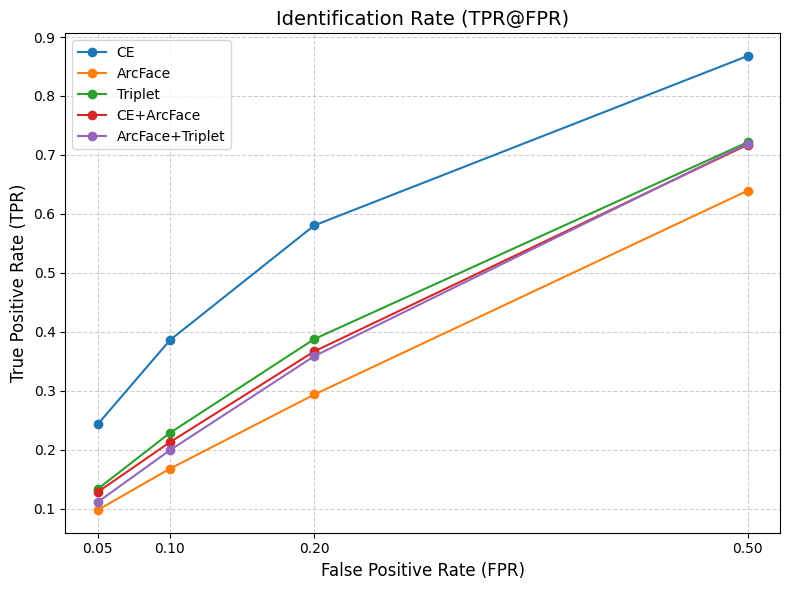

In [ ]:
plot_tpr_curves(df)

Что мы видим:

CE уверенно лидирует по всем значениям FPR. При жёстких ограничениях все модели вызывают желание обнять и заплакать, но CE и там дает наилучший результат.

ArcFace, напротив, показывает наихудшие результаты. Особенно заметен спад при строгих порогах. Возможно, ему для полноценного обучения нужно большее количество классов, чем 500.

Triplet Loss - фторой по качеству после CE. При снижении FPR метрика ухудшается, но остаётся выше, чем у остальных трех моделей. Это ожидаемо: Triplet учился на идейно близком датасете (anchor–positive–negative).

CE + ArcFace и ArcFace + Triplet показывают промежуточные результаты. Их TPR заметно ниже, чем у лучших одиночных моделей (CE или Triplet), особенно при строгих порогах. При этом они не демонстрируют значительных преимуществ над более простыми архитектурами.

